# Transformación y Reducción de Datos

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.transformacion import TransformacionDatos

1. Importación de la clase

In [3]:
from src.transformacion import TransformacionDatos

print("Clase cargada correctamente")

Clase cargada correctamente


2. Inicialización de la transformación

In [4]:
transformacion = TransformacionDatos(
    "../dataset/dataset_integrado.csv"
)

3. Carga del dataset integrado

In [5]:
df = transformacion.cargar()

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (3047, 11)


,FECHA,ACCIDENTES,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,PRECIPITACION_MM,LLUVIA,COMPARENDOS,COD_INFRACCION,TIPO_INFRACCION,CLASE_VEHICULO_INFRACTOR,SERVICIO_VEHICULO_INFRACTOR
0,2018-01-01,7.0,Solo daños,Choque,0.0,No,293.0,C29,TRÁNSITO,AUTOMOVIL,PARTICULAR
1,2018-01-02,11.0,Solo daños,Choque,0.0,No,347.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
2,2018-01-03,12.0,Solo daños,Choque,0.0,No,269.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
3,2018-01-04,16.0,Solo daños,Choque,4.5,Sí,253.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
4,2018-01-05,12.0,Solo daños,Choque,0.0,No,317.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR


4. Diagnóstico inicial de los datos

In [6]:
transformacion.diagnosticar()

Filas: 3047
Columnas: 11

Valores nulos:
FECHA                             0
ACCIDENTES                        0
GRAVEDAD_ACCIDENTE                0
CLASE_ACCIDENTE                   0
PRECIPITACION_MM               2443
LLUVIA                         2443
COMPARENDOS                      18
COD_INFRACCION                   18
TIPO_INFRACCION                  18
CLASE_VEHICULO_INFRACTOR         18
SERVICIO_VEHICULO_INFRACTOR      18
dtype: int64

Duplicados: 0


5. Tratamiento de valores nulos

In [7]:
df_tratado = transformacion.tratar_nulos()

print("Dimensiones:", df_tratado.shape)
df_tratado.head()

Dimensiones: (3047, 12)


,FECHA,ACCIDENTES,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,PRECIPITACION_MM,LLUVIA,COMPARENDOS,COD_INFRACCION,TIPO_INFRACCION,CLASE_VEHICULO_INFRACTOR,SERVICIO_VEHICULO_INFRACTOR,PRECIPITACION_FALTANTE
0,2018-01-01,7.0,Solo daños,Choque,0.0,No,293.0,C29,TRÁNSITO,AUTOMOVIL,PARTICULAR,0
1,2018-01-02,11.0,Solo daños,Choque,0.0,No,347.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR,0
2,2018-01-03,12.0,Solo daños,Choque,0.0,No,269.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR,0
3,2018-01-04,16.0,Solo daños,Choque,4.5,Sí,253.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR,0
4,2018-01-05,12.0,Solo daños,Choque,0.0,No,317.0,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR,0


6. Codificación de variables categóricas

In [8]:
df_codificado = transformacion.codificar()

print("Dimensiones:", df_codificado.shape)
df_codificado.head()

Dimensiones: (3047, 26)


,FECHA,ACCIDENTES,GRAVEDAD_ACCIDENTE,PRECIPITACION_MM,COMPARENDOS,PRECIPITACION_FALTANTE,CLASE_ACCIDENTE_Atropello,CLASE_ACCIDENTE_Caida Ocupante,CLASE_ACCIDENTE_Choque,CLASE_ACCIDENTE_Otro,...,COD_INFRACCION_C29,COD_INFRACCION_Sin dato,TIPO_INFRACCION_Sin dato,TIPO_INFRACCION_TRÁNSITO,CLASE_VEHICULO_INFRACTOR_AUTOMOVIL,CLASE_VEHICULO_INFRACTOR_CAMIONETA,CLASE_VEHICULO_INFRACTOR_MOTOCICLETA,CLASE_VEHICULO_INFRACTOR_Sin dato,SERVICIO_VEHICULO_INFRACTOR_PARTICULAR,SERVICIO_VEHICULO_INFRACTOR_Sin dato
0,2018-01-01,7.0,0,0.0,293.0,0,0,0,1,0,...,1,0,0,1,1,0,0,0,1,0
1,2018-01-02,11.0,0,0.0,347.0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,1,0
2,2018-01-03,12.0,0,0.0,269.0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,1,0
3,2018-01-04,16.0,0,4.5,253.0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,1,0
4,2018-01-05,12.0,0,0.0,317.0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,1,0


7. Comparación de métodos de escalamiento

In [9]:
resultados_escalamiento = transformacion.comparar_escaladores()

print(resultados_escalamiento.keys())

dict_keys(['MinMaxScaler', 'StandardScaler', 'RobustScaler'])


8. Escalamiento con RobustScaler

In [10]:
df_escalado = transformacion.escalar()

df_escalado[
    ["ACCIDENTES", "PRECIPITACION_MM", "COMPARENDOS"]
].head()

,ACCIDENTES,PRECIPITACION_MM,COMPARENDOS
0,-0.1,0.0,0.801980
1,0.3,0.0,1.336634
2,0.4,0.0,0.564356
3,0.8,4.5,0.405941
4,0.4,0.0,1.039604


9. Reducción de dimensionalidad mediante PCA

In [11]:
df_reducido = transformacion.aplicar_pca()

print("Dimensiones:", df_reducido.shape)
df_reducido.head()

Dimensiones: (3047, 7)


,FECHA,PRECIPITACION_FALTANTE,PC1,PC2,PC3,PC4,PC5
0,2018-01-01,0,0.531862,0.289270,-0.335802,1.575632,0.258763
1,2018-01-02,0,1.621736,-0.433032,-0.081737,0.767982,0.361188
2,2018-01-03,0,1.248116,-0.026786,-0.288741,0.335297,0.616185
3,2018-01-04,0,1.871542,2.613376,3.431672,-0.174461,-0.006906
4,2018-01-05,0,1.509021,-0.254805,-0.182906,0.588118,0.442430


10. Varianza explicada

In [16]:
print("Varianza explicada:")
print(transformacion.varianza_explicada)

print("\nVarianza acumulada:")
print(transformacion.varianza_acumulada * 100)

Varianza explicada:
[3.14217005e-01 2.48556409e-01 2.18719663e-01 1.11661981e-01
 3.48886015e-02 2.60504842e-02 1.93855641e-02 1.73043053e-02
 6.55426868e-03 1.29185186e-03 5.99655142e-04 4.06940785e-04
 2.23163619e-04 1.40106622e-04 6.00066110e-17 1.77096790e-17
 6.52404086e-18 7.68226977e-19 2.01822211e-19 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Varianza acumulada:
[ 31.42170049  56.27734138  78.14930773  89.31550583  92.80436598
  95.4094144   97.3479708   99.07840133  99.7338282   99.86301338
  99.9229789   99.96367298  99.98598934 100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.        ]


11. Dataset reducido

In [17]:
df_reducido.head(10)

,FECHA,PRECIPITACION_FALTANTE,PC1,PC2,PC3,PC4,PC5
0,2018-01-01,0,0.020885,0.026722,-0.077056,1.306593,-0.491251
1,2018-01-02,0,1.330266,-0.369745,0.041696,0.564302,-0.413833
2,2018-01-03,0,0.870083,-0.091913,-0.217867,0.071855,-0.334476
3,2018-01-04,0,1.762129,3.772906,2.223362,-0.125106,-0.064800
4,2018-01-05,0,1.179269,-0.242072,-0.094101,0.374815,-0.346479
5,2018-01-06,0,0.615274,-0.022503,-0.244511,-0.136295,-0.386074
6,2018-01-07,0,-0.068544,0.178834,-0.263563,1.135906,-0.364796
7,2018-01-08,0,-0.261785,0.272684,-0.340916,0.946555,-0.357294
8,2018-01-09,0,0.622374,-0.607069,0.539994,0.137721,0.213075
9,2018-01-10,0,1.289522,-0.186937,-0.200676,0.399790,-0.227777


12. Guardar dataset reducido

In [14]:
transformacion.guardar_reducido(
    "../dataset/dataset_reducido.csv"
)

Dataset reducido guardado en: ../dataset/dataset_reducido.csv


13. Visualización de la varianza explicada por PCA

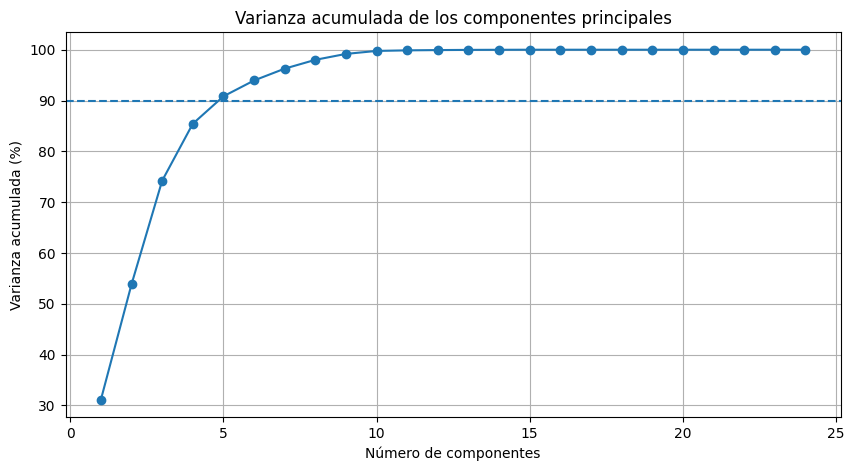

In [15]:
import matplotlib.pyplot as plt

componentes = range(1, len(transformacion.varianza_explicada) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    componentes,
    transformacion.varianza_acumulada * 100,
    marker="o"
)

plt.axhline(
    y=90,
    linestyle="--"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.title("Varianza acumulada de los componentes principales")
plt.grid(True)

plt.show()

14. Identificación del patrón comportamental

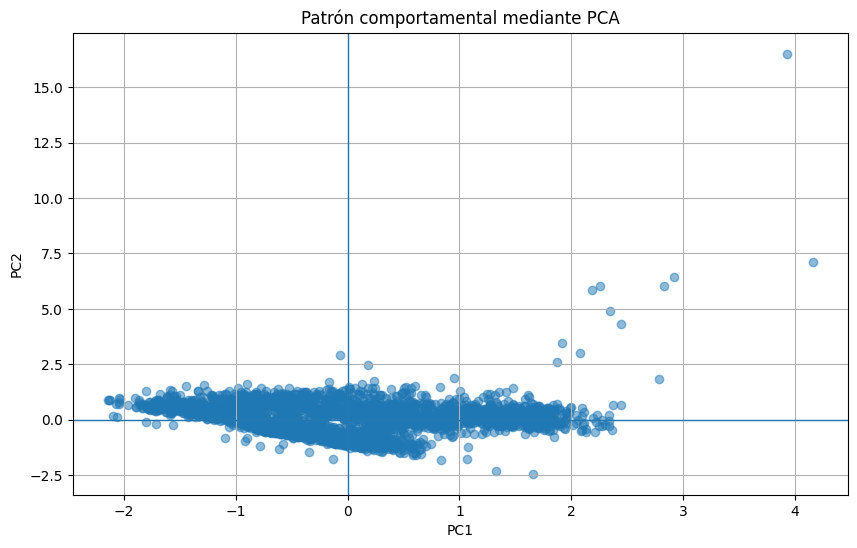

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_reducido["PC1"],
    df_reducido["PC2"],
    alpha=0.5
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patrón comportamental mediante PCA")

plt.grid(True)
plt.show()

Interpretación

El gráfico de PC1 frente a PC2 permite visualizar agrupaciones y comportamientos similares entre los días analizados. Los puntos cercanos representan días con características similares considerando las variables incluidas en el análisis de componentes principales.

Los cinco componentes seleccionados conservan aproximadamente el 90.83 % de la variabilidad total del conjunto de datos, por lo que permiten representar de forma reducida los principales patrones presentes en los accidentes, las precipitaciones y los comparendos.